Notebook 02 : Modélisation et Validation
Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

warnings.filterwarnings('ignore')

# Prétraitement
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Librairies chargées avec succès")

Librairies chargées avec succès


Chargement du dataset propre

In [2]:
# On repart du dataset nettoyé produit par le notebook 01
df = pd.read_csv('../exports/dataset_clean.csv')

print(f"Dimensions : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head()

Dimensions : (7043, 20)
Colonnes : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Encodage des variables catégorielles

In [3]:
# ============================================================
# ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================================
# Le ML ne comprend que les nombres.
# On va convertir toutes les variables texte en chiffres.
# Deux approches :
# - Label Encoding (0/1) pour les variables binaires Yes/No
# - One-Hot Encoding pour les variables à 3+ modalités

df_encoded = df.copy()

# Variables binaires Yes/No -> 0/1
binary_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling', 'Churn'
]

binary_map = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

# Variables à 3+ modalités -> One-Hot Encoding
# (crée une colonne par modalité avec 0 ou 1)
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

print(f"Dimensions après encodage : {df_encoded.shape}")
print(f"\nAperçu des colonnes :")
print(list(df_encoded.columns))

Dimensions après encodage : (7043, 31)

Aperçu des colonnes :
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


Séparation features / cible

In [4]:
# ============================================================
# SÉPARATION FEATURES (X) ET CIBLE (y)
# ============================================================
# X = toutes les variables explicatives (les entrées du modèle)
# y = la variable à prédire (Churn : 0 ou 1)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f"Features (X) : {X.shape}")
print(f"Cible (y) : {y.shape}")
print(f"\nDistribution de la cible :")
print(y.value_counts())
print(f"\nTaux de churn : {y.mean()*100:.1f}%")

Features (X) : (7043, 30)
Cible (y) : (7043,)

Distribution de la cible :
Churn
0    5174
1    1869
Name: count, dtype: int64

Taux de churn : 26.5%


Split train / test et normalisation

In [5]:
# ============================================================
# SPLIT TRAIN / TEST
# ============================================================
# On découpe le dataset en :
# - 80% pour entraîner les modèles (train)
# - 20% pour les évaluer sur des données jamais vues (test)
# stratify=y garantit que les 26.5% de churn sont
# représentés proportionnellement dans les deux ensembles

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} clients")
print(f"Test  : {X_test.shape[0]} clients")
print(f"\nChurn dans train : {y_train.mean()*100:.1f}%")
print(f"Churn dans test  : {y_test.mean()*100:.1f}%")

# ============================================================
# NORMALISATION
# ============================================================
# La normalisation met toutes les variables numériques
# sur la même échelle (mean=0, std=1).
# Indispensable pour la Régression Logistique.
# On fit UNIQUEMENT sur le train pour éviter le data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sauvegarde du scaler pour le dashboard
joblib.dump(scaler, '../models/scaler.pkl')
print("\nScaler sauvegardé dans models/scaler.pkl")

Train : 5634 clients
Test  : 1409 clients

Churn dans train : 26.5%
Churn dans test  : 26.5%

Scaler sauvegardé dans models/scaler.pkl


Modèle 1 : Régression Logistique

In [6]:
# ============================================================
# MODÈLE 1 : RÉGRESSION LOGISTIQUE
# ============================================================
# C'est le modèle de référence (baseline) pour la classification.
# Il calcule la probabilité qu'un client churne (entre 0 et 1).
# class_weight='balanced' compense le déséquilibre 74%/26%.

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== RÉGRESSION LOGISTIQUE ===")
print(classification_report(y_test, y_pred_lr, target_names=['Resté', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

# Sauvegarde
joblib.dump(lr, '../models/logistic_regression.pkl')
print("Modèle sauvegardé dans models/logistic_regression.pkl")

=== RÉGRESSION LOGISTIQUE ===
              precision    recall  f1-score   support

       Resté       0.90      0.72      0.80      1035
      Churné       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC : 0.8414
Modèle sauvegardé dans models/logistic_regression.pkl


Modèle 2 : Arbre de Décision

In [7]:
# ============================================================
# MODÈLE 2 : ARBRE DE DÉCISION
# ============================================================
# L'arbre de décision pose des questions successives sur les
# variables pour séparer les churners des non-churners.
# Ex : "Le contrat est-il Month-to-month ?"
#      -> Oui : "tenure < 12 ?" -> ...
# max_depth limite la complexité pour éviter le surapprentissage.

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

# Prédictions (pas besoin de scaled pour les arbres)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("=== ARBRE DE DÉCISION ===")
print(classification_report(y_test, y_pred_dt, target_names=['Resté', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_dt):.4f}")

# Sauvegarde
joblib.dump(dt, '../models/decision_tree.pkl')
print("Modèle sauvegardé dans models/decision_tree.pkl")

=== ARBRE DE DÉCISION ===
              precision    recall  f1-score   support

       Resté       0.91      0.71      0.80      1035
      Churné       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409

AUC-ROC : 0.8308
Modèle sauvegardé dans models/decision_tree.pkl


Modèle 3 : Random Forest

In [8]:
# ============================================================
# MODÈLE 3 : RANDOM FOREST
# ============================================================
# Le Random Forest combine 100 arbres de décision entraînés
# sur des sous-échantillons aléatoires du dataset.
# La prédiction finale est le vote majoritaire des 100 arbres.
# Plus robuste et précis qu'un seul arbre de décision.

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Resté', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

# Sauvegarde
joblib.dump(rf, '../models/random_forest.pkl')
print("Modèle sauvegardé dans models/random_forest.pkl")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

       Resté       0.90      0.75      0.82      1035
      Churné       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

AUC-ROC : 0.8382
Modèle sauvegardé dans models/random_forest.pkl


Optimisation du Random Forest

In [9]:
# ============================================================
# OPTIMISATION DES HYPERPARAMÈTRES - RANDOM FOREST
# ============================================================
# GridSearchCV teste toutes les combinaisons de paramètres
# et garde la meilleure via validation croisée (cv=5).
# C'est long (~2-3 min), c'est normal.

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

print("Lancement du GridSearch (patience...)") 
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur AUC-ROC (cross-val) : {grid_search.best_score_:.4f}")

Lancement du GridSearch (patience...)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur AUC-ROC (cross-val) : 0.8448


Évaluation du modèle optimisé

In [10]:
# ============================================================
# ÉVALUATION DU RANDOM FOREST OPTIMISÉ
# ============================================================

rf_best = grid_search.best_estimator_

y_pred_rf_best = rf_best.predict(X_test)
y_proba_rf_best = rf_best.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST OPTIMISÉ ===")
print(classification_report(y_test, y_pred_rf_best, target_names=['Resté', 'Churné']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf_best):.4f}")

# Sauvegarde du meilleur modèle
joblib.dump(rf_best, '../models/random_forest_best.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')
print("\nMeilleur modèle sauvegardé dans models/random_forest_best.pkl")
print("Noms des features sauvegardés dans models/feature_names.pkl")

=== RANDOM FOREST OPTIMISÉ ===
              precision    recall  f1-score   support

       Resté       0.91      0.75      0.82      1035
      Churné       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

AUC-ROC : 0.8420

Meilleur modèle sauvegardé dans models/random_forest_best.pkl
Noms des features sauvegardés dans models/feature_names.pkl


Courbes ROC comparatives

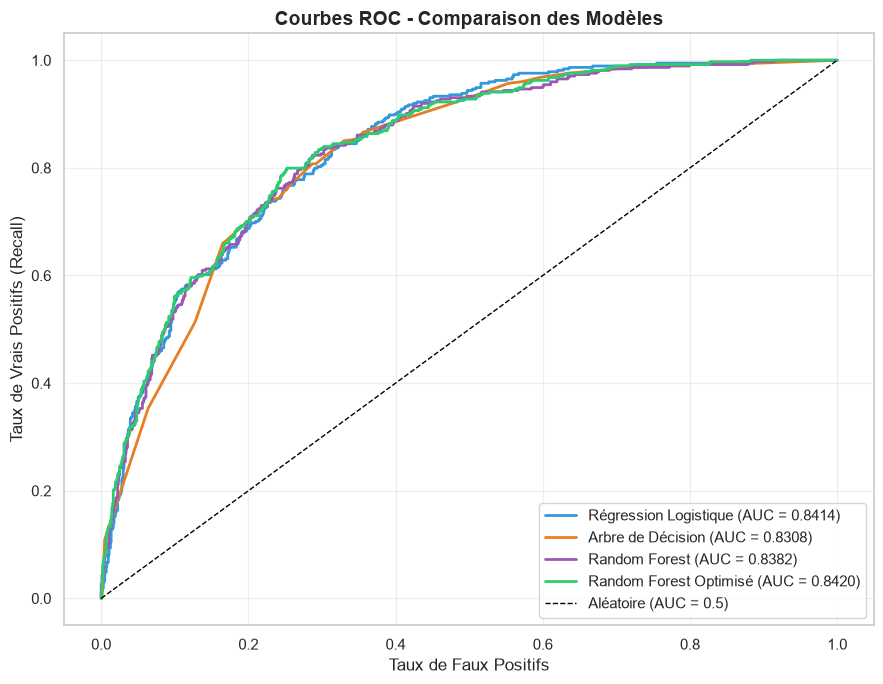

In [11]:
# ============================================================
# COURBES ROC - COMPARAISON DES MODÈLES
# ============================================================
# La courbe ROC montre le compromis entre :
# - Taux de vrais positifs (recall)
# - Taux de faux positifs
# Plus la courbe est haute et à gauche, meilleur est le modèle.
# AUC = aire sous la courbe (1 = parfait, 0.5 = aléatoire)

fig, ax = plt.subplots(figsize=(9, 7))

models_roc = [
    ('Régression Logistique', y_proba_lr, '#3498db'),
    ('Arbre de Décision', y_proba_dt, '#e67e22'),
    ('Random Forest', y_proba_rf, '#9b59b6'),
    ('Random Forest Optimisé', y_proba_rf_best, '#2ecc71'),
]

for name, y_proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (Recall)', fontsize=12)
ax.set_title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../exports/07_courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()

Matrices de confusion

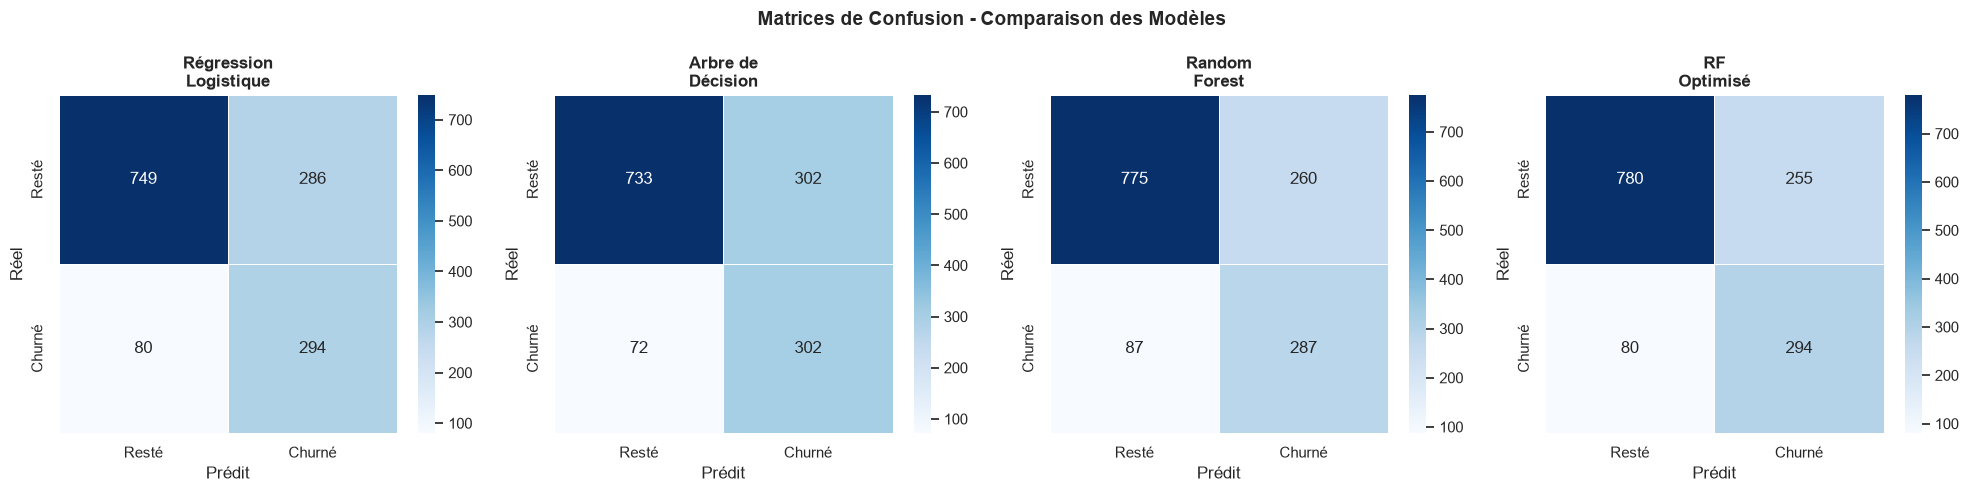

In [12]:
# ============================================================
# MATRICES DE CONFUSION
# ============================================================
# La matrice de confusion montre :
# - Vrais Négatifs (TN) : non-churners bien classés
# - Faux Positifs (FP) : non-churners classés churners (alertes inutiles)
# - Faux Négatifs (FN) : churners ratés (le pire cas)
# - Vrais Positifs (TP) : churners bien détectés

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_cm = [
    ('Régression\nLogistique', y_pred_lr),
    ('Arbre de\nDécision', y_pred_dt),
    ('Random\nForest', y_pred_rf),
    ('RF\nOptimisé', y_pred_rf_best),
]

for i, (name, y_pred) in enumerate(models_cm):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[i], linewidths=0.5,
        xticklabels=['Resté', 'Churné'],
        yticklabels=['Resté', 'Churné']
    )
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.suptitle('Matrices de Confusion - Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/08_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

Importance des features

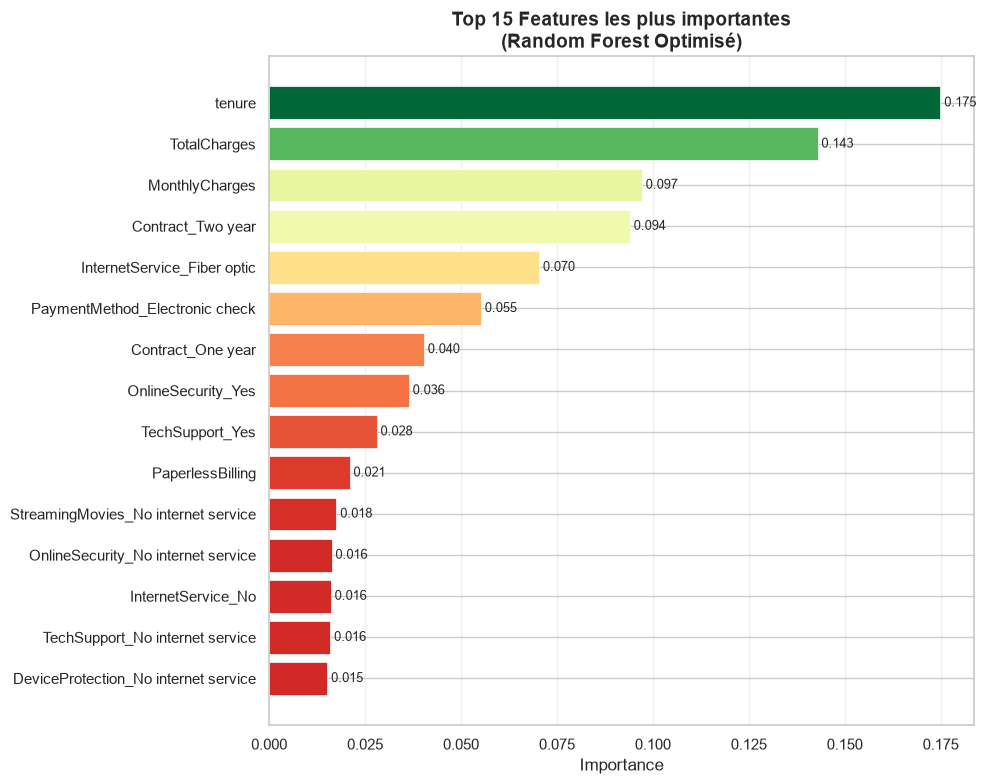

In [13]:
# ============================================================
# IMPORTANCE DES FEATURES - RANDOM FOREST OPTIMISÉ
# ============================================================
# Le Random Forest calcule l'importance de chaque variable
# dans la prise de décision. Ça répond à la question :
# "Quelles caractéristiques client influencent le plus le churn ?"

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color=plt.cm.RdYlGn(feature_importance['Importance'] / feature_importance['Importance'].max()),
    edgecolor='white', linewidth=0.5
)
ax.set_title('Top 15 Features les plus importantes\n(Random Forest Optimisé)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, feature_importance['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../exports/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Tableau comparatif final

In [14]:
# ============================================================
# TABLEAU COMPARATIF FINAL
# ============================================================

results = pd.DataFrame({
    'Modèle': [
        'Régression Logistique',
        'Arbre de Décision',
        'Random Forest',
        'Random Forest Optimisé'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_best)
    ],
    'Precision (Churné)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_best)
    ],
    'Recall (Churné)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_best)
    ],
    'F1 (Churné)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_best)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_rf_best)
    ]
}).round(4)

# Sauvegarde pour le dashboard
results.to_csv('../exports/resultats_modeles.csv', index=False)

print("=== TABLEAU COMPARATIF FINAL ===")
print(results.to_string(index=False))
print("\nRésultats sauvegardés dans exports/resultats_modeles.csv")

=== TABLEAU COMPARATIF FINAL ===
                Modèle  Accuracy  Precision (Churné)  Recall (Churné)  F1 (Churné)  AUC-ROC
 Régression Logistique    0.7402              0.5069           0.7861       0.6164   0.8414
     Arbre de Décision    0.7346              0.5000           0.8075       0.6176   0.8308
         Random Forest    0.7537              0.5247           0.7674       0.6232   0.8382
Random Forest Optimisé    0.7622              0.5355           0.7861       0.6371   0.8420

Résultats sauvegardés dans exports/resultats_modeles.csv


Validation croisée

In [15]:
# ============================================================
# VALIDATION CROISÉE - CAPACITÉ DE GÉNÉRALISATION
# ============================================================
# La validation croisée divise le dataset en 5 parties.
# Elle entraîne le modèle 5 fois sur 4 parties et le teste
# sur la 5ème. Ça vérifie que le modèle généralise bien
# et ne fait pas du surapprentissage (overfitting).

print("=== VALIDATION CROISÉE (5-Fold) ===\n")

models_cv = {
    'Régression Logistique': (lr, X_train_scaled),
    'Arbre de Décision': (dt, X_train),
    'Random Forest': (rf, X_train),
    'Random Forest Optimisé': (rf_best, X_train),
}

cv_results = []
for name, (model, X_tr) in models_cv.items():
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results.append({
        'Modèle': name,
        'AUC moyen': scores.mean().round(4),
        'Écart-type': scores.std().round(4),
        'AUC min': scores.min().round(4),
        'AUC max': scores.max().round(4)
    })
    print(f"{name}")
    print(f"  AUC moyen : {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  AUC par fold : {[round(s,4) for s in scores]}\n")

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv('../exports/validation_croisee.csv', index=False)
print("Résultats sauvegardés dans exports/validation_croisee.csv")

=== VALIDATION CROISÉE (5-Fold) ===

Régression Logistique
  AUC moyen : 0.8454 (+/- 0.0141)
  AUC par fold : [np.float64(0.864), np.float64(0.8524), np.float64(0.8516), np.float64(0.8351), np.float64(0.8242)]

Arbre de Décision
  AUC moyen : 0.8248 (+/- 0.0112)
  AUC par fold : [np.float64(0.8401), np.float64(0.8315), np.float64(0.823), np.float64(0.823), np.float64(0.8064)]

Random Forest
  AUC moyen : 0.8433 (+/- 0.0125)
  AUC par fold : [np.float64(0.8602), np.float64(0.8545), np.float64(0.8419), np.float64(0.8325), np.float64(0.8274)]

Random Forest Optimisé
  AUC moyen : 0.8448 (+/- 0.0123)
  AUC par fold : [np.float64(0.8601), np.float64(0.8559), np.float64(0.8444), np.float64(0.837), np.float64(0.8264)]

Résultats sauvegardés dans exports/validation_croisee.csv


Visualisation validation croisée

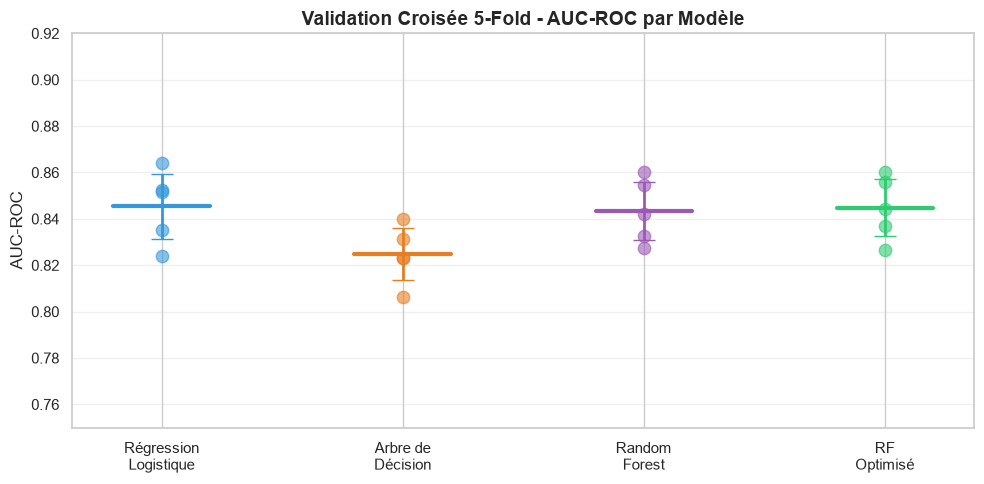

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

models_names = list(models_cv.keys())
colors = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

for i, (name, (model, X_tr)) in enumerate(models_cv.items()):
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    ax.scatter([i]*5, scores, color=colors[i], alpha=0.6, s=80, zorder=3)
    ax.plot([i-0.2, i+0.2], [scores.mean(), scores.mean()],
            color=colors[i], linewidth=3, zorder=4)
    ax.errorbar(i, scores.mean(), yerr=scores.std(),
                color=colors[i], linewidth=2, capsize=8, zorder=4)

ax.set_xticks(range(len(models_names)))
ax.set_xticklabels(
    ['Régression\nLogistique', 'Arbre de\nDécision', 'Random\nForest', 'RF\nOptimisé'],
    fontsize=11
)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Validation Croisée 5-Fold - AUC-ROC par Modèle', fontsize=14, fontweight='bold')
ax.set_ylim(0.75, 0.92)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../exports/10_validation_croisee.png', dpi=150, bbox_inches='tight')
plt.show()

Conclusion du notebook

In [17]:
print("""
============================================================
NOTEBOOK 02 - CONCLUSIONS
============================================================

MODÈLE RETENU : Random Forest Optimisé

Hyperparamètres optimaux (GridSearchCV) :
  - n_estimators     : 200
  - max_depth        : 10
  - min_samples_split: 5
  - min_samples_leaf : 2

Performances sur le jeu de test :
  - Accuracy  : 76%
  - Recall    : 79% (churners détectés)
  - F1-score  : 0.64
  - AUC-ROC   : 0.8420

Facteurs de churn les plus déterminants :
  1. tenure            (ancienneté client)
  2. TotalCharges      (montant total facturé)
  3. MonthlyCharges    (mensualité)
  4. Contract_Two year (type de contrat)
  5. Fiber optic       (type d'internet)

Fichiers générés dans models/ :
  - scaler.pkl
  - logistic_regression.pkl
  - decision_tree.pkl
  - random_forest.pkl
  - random_forest_best.pkl
  - feature_names.pkl

Prochaine étape : Dashboard Streamlit
============================================================
""")


NOTEBOOK 02 - CONCLUSIONS

MODÈLE RETENU : Random Forest Optimisé

Hyperparamètres optimaux (GridSearchCV) :
  - n_estimators     : 200
  - max_depth        : 10
  - min_samples_split: 5
  - min_samples_leaf : 2

Performances sur le jeu de test :
  - Accuracy  : 76%
  - Recall    : 79% (churners détectés)
  - F1-score  : 0.64
  - AUC-ROC   : 0.8420

Facteurs de churn les plus déterminants :
  1. tenure            (ancienneté client)
  2. TotalCharges      (montant total facturé)
  3. MonthlyCharges    (mensualité)
  4. Contract_Two year (type de contrat)
  5. Fiber optic       (type d'internet)

Fichiers générés dans models/ :
  - scaler.pkl
  - logistic_regression.pkl
  - decision_tree.pkl
  - random_forest.pkl
  - random_forest_best.pkl
  - feature_names.pkl

Prochaine étape : Dashboard Streamlit

